## Need to work out how to generate multiple code phases
The correlator needs to work out how to generate phase offsets
Check that assigining a new seed to the G2, generates a new phase offset, from this we can load G2 with all values from "all-1's" to ...0001 and worth through each code phase.

Using ca code generation from natronics, validated against the octal from the NAVSTAR reference

In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
#SV and G2 combination taps mapping here
SV = {
   1: [2,6],
   2: [3,7],
   3: [4,8],
   4: [5,9],
   5: [1,9],
   6: [2,10],
   7: [1,8],
   8: [2,9],
   9: [3,10],
  10: [2,3],
  11: [3,4],
  12: [5,6],
  13: [6,7],
  14: [7,8],
  15: [8,9],
  16: [9,10],
  17: [1,4],
  18: [2,5],
  19: [3,6],
  20: [4,7],
  21: [5,8],
  22: [6,9],
  23: [1,3],
  24: [4,6],
  25: [5,7],
  26: [6,8],
  27: [7,9],
  28: [8,10],
  29: [1,6],
  30: [2,7],
  31: [3,8],
  32: [4,9],
}

def shift(register, feedback, output):
    """GPS Shift Register
    
    :param list feedback: which positions to use as feedback (1 indexed)
    :param list output: which positions are output (1 indexed)
    :returns output of shift register:
    
    """
    
    # calculate output
    out = [register[i-1] for i in output]
    if len(out) > 1:
        out = sum(out) % 2
    else:
        out = out[0]
        
    # modulo 2 add feedback
    fb = sum([register[i-1] for i in feedback]) % 2
    
    # shift to the right
    for i in reversed(range(len(register[1:]))):
        register[i+1] = register[i]
        
    # put feedback in position 1
    register[0] = fb
    
    return out


def PRN(sv, g2init = [1 for i in range(10)]):
    """Build the CA code (PRN) for a given satellite ID
    
    :param int sv: satellite code (1-32)
    :returns list: ca code for chosen satellite
    
    """
    
    # init registers
    G1 = [1 for i in range(10)]
    G2 = g2init

    ca = [] # stuff output in here
    
    # create sequence
    for i in range(1023):
        #print("step" + str(i))
        g1 = shift(G1, [3,10], [10])
        #print("G1 SR: " + str(G1))
        g2 = shift(G2, [2,3,6,8,9,10], SV[sv]) # <- sat chosen here from table
        #print("G2 SR: " + str(G2))
        
        #print("g1 out " + str(g1))
        #print("g2 out " + str(g2))
        #print("gl out " + str((g1 + g2)%2))
        # modulo 2 add and append to the code
        ca.append((g1 + g2) % 2)

    # return C/A code!
    return ca


In [5]:
ca_one_code = PRN(1)
ca_two_code = PRN(2)
print(ca_one_code[:10])
print(len(ca_one_code))
print(ca_two_code[:10])
ca_one_code_shift = PRN(1, g2init = [0,0,0,0,0,0,0,0,0,1])
print(ca_one_code_shift[:10])
print(len(ca_one_code_shift))
#convert from 0-1 to 1 - -1
ca_one_code = (np.array(ca_one_code) * 2) -1;
ca_two_code = (np.array(ca_two_code) * 2) -1;
ca_one_code_shift = (np.array(ca_one_code_shift) * 2) -1


[1, 1, 0, 0, 1, 0, 0, 0, 0, 0]
1023
[1, 1, 1, 0, 0, 1, 0, 0, 0, 0]
[1, 1, 0, 1, 0, 0, 1, 1, 1, 1]
1023


2046
1024


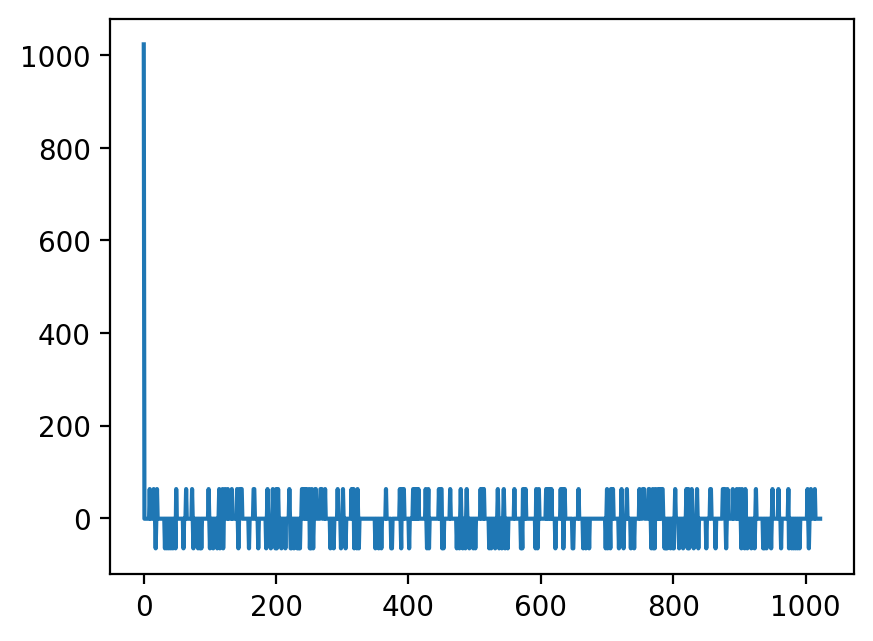

In [6]:
#try auto correlation first
ca_one_code_concat = np.concatenate((ca_one_code, ca_one_code))
print(len(ca_one_code_concat))
auto_corl_ca_one = np.correlate(ca_one_code, ca_one_code_concat)
print(len(auto_corl_ca_one))
plt.plot(auto_corl_ca_one[:-1])

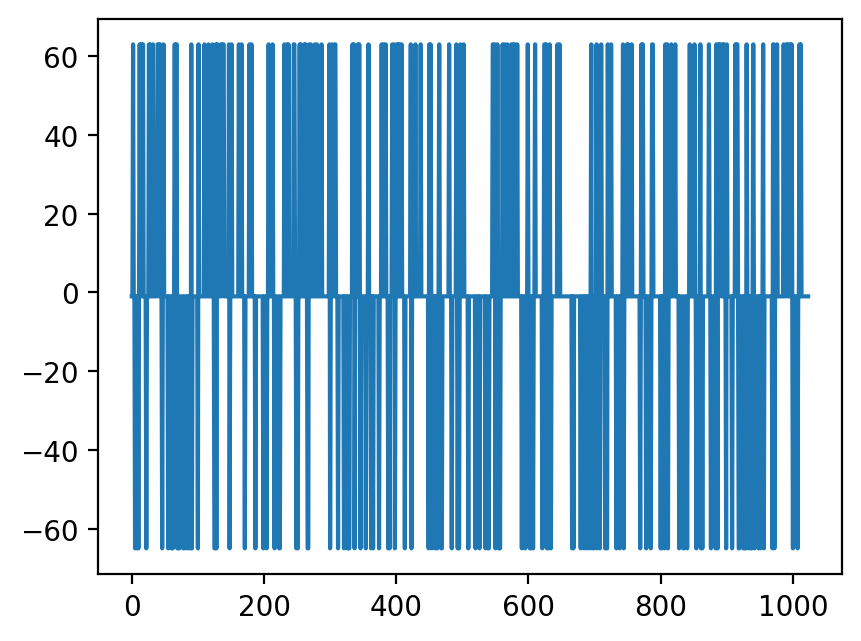

In [9]:
#try cross corellation
cross_corl_ca_one_two = np.correlate(ca_two_code, ca_one_code_concat)
plt.plot(cross_corl_ca_one_two)

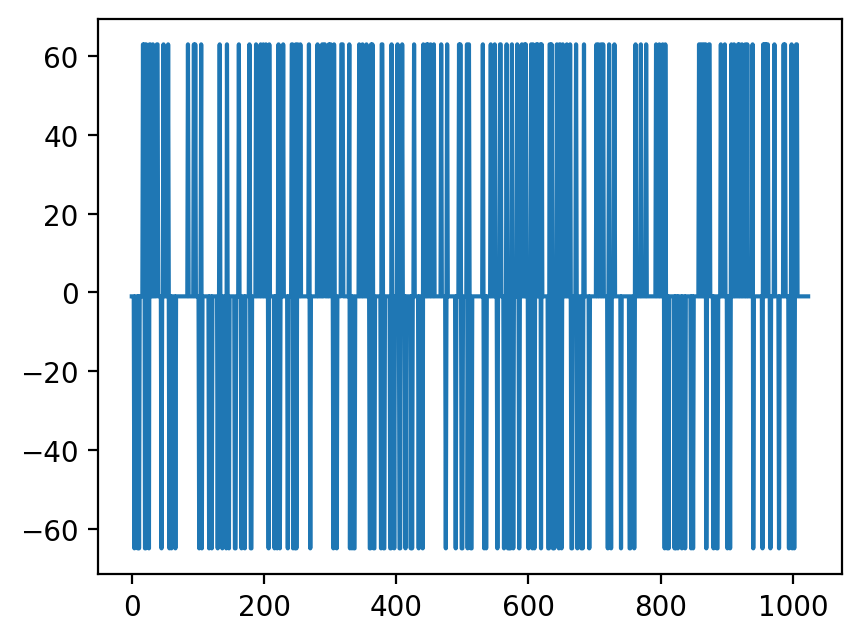

In [10]:
#try delay functionalith
cross_corl_code_shift = np.correlate(ca_one_code_shift,ca_one_code_concat)
plt.plot(cross_corl_code_shift)
#doesn't work... probably would need to maintain a mapping of G1 and G2 values, and initialise both to desired offsets (which would need SW intervention/loading). Use other technique of delaying by a number of clock cycles. Though may need multiple LFSR's one for the current and one for the next code phase test.